In [1]:
import pandas as pd

In [2]:
from nselib import capital_market as cm

# Define dates as strings in DD-MM-YYYY format
start_date = '01-06-2021'
end_date = '05-01-2022'

# Use the correct function: price_volume_data
stk_data = cm.price_volume_data(symbol='TATACOFFEE', from_date=start_date, to_date=end_date)

print(stk_data.head())

       Symbol Series         Date  PrevClose  OpenPrice  HighPrice  LowPrice  \
0  TATACOFFEE     EQ  05-Jan-2022     217.80     218.50      218.7    214.30   
1  TATACOFFEE     EQ  04-Jan-2022     214.05     214.90      220.8    212.45   
2  TATACOFFEE     EQ  03-Jan-2022     213.15     213.95      216.9    212.30   
3  TATACOFFEE     EQ  31-Dec-2021     208.50     208.90      216.2    208.40   
4  TATACOFFEE     EQ  30-Dec-2021     211.35     211.45      211.5    207.90   

   LastPrice  ClosePrice  AveragePrice TotalTradedQuantity        Turnover₹  \
0     214.65      214.85        215.72           13,50,483  29,13,25,687.40   
1     217.40      217.80        217.41           34,77,443  75,60,37,979.15   
2     214.30      214.05        214.76           15,25,259  32,75,66,528.25   
3     213.70      213.15        213.37           30,45,699  64,98,54,073.20   
4     208.80      208.50        209.36            9,77,484  20,46,47,553.50   

  No.ofTrades  
0      12,079  
1      28,87

In [3]:
stk_data=stk_data[["OpenPrice","HighPrice","LowPrice","ClosePrice"]]
stk_data.to_csv("Tatacoffee13_21.csv")

In [4]:
column="ClosePrice"

In [5]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (151, 1)


In [6]:
training_size = round(len(data1 ) * 0.95)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

143
X_train length: (143, 1)
X_test length: (8, 1)
y_train length: (143, 1)
y_test length: (8, 1)


In [7]:
import warnings
warnings.filterwarnings("ignore")

In [8]:
from sklearn.metrics import mean_squared_error
trends=['n','t','c','ct']
orders=[(0,0,1),(0,0,2)]
from statsmodels.tsa.arima.model import ARIMA
for td in trends:
    model = ARIMA(X_train, order=(0,0,10),trend=td,)
    model_fit = model.fit()
        # make prediction
    y_pred= model_fit.predict(len(X_train), len(data1)-1)
    from sklearn.metrics import r2_score
    mse=mean_squared_error(y_test,y_pred,squared=False)
    from stockFunctions import rmsemape
    print("Trend={}".format(td))
    rmsemape(y_test,y_pred)
    print("************")

C:\Anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Trend=n
RMSE-Testset: 0.09725295140994508
maPe-Testset: 1.8159592481838065
************


C:\Anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Trend=t
RMSE-Testset: 0.5121985007739944
maPe-Testset: 16.773074655315206
************
Trend=c
RMSE-Testset: 0.3892220277206179
maPe-Testset: 12.747796360899878
************
Trend=ct
RMSE-Testset: 0.23726086551395487
maPe-Testset: 7.656573896489003
************


C:\Anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [9]:
len(y_pred)

8

In [10]:
#i=1
td="c"
model = ARIMA(X_train, order=(0,0,30),trend=td)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(X_train), len(data1)-1)
#print(y_pred)
from sklearn.metrics import r2_score
mse=mean_squared_error(y_test,y_pred,squared=False)
from stockFunctions import rmsemape
print("Trend={}".format(td))
rmsemape(y_test,y_pred)
print("************")

C:\Anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Trend=c
RMSE-Testset: 0.33206961613667935
maPe-Testset: 10.44793127506706
************


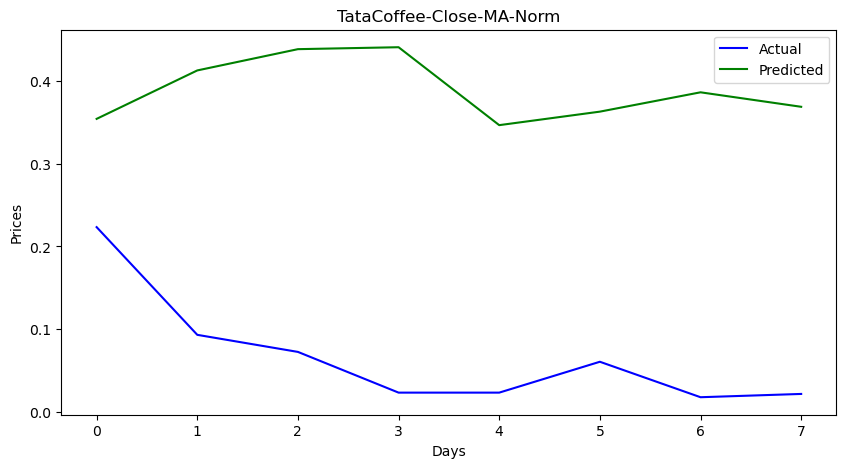

In [11]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-Close-MA-Norm","Days","Prices")

In [12]:
len(data1)

151

In [13]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [14]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

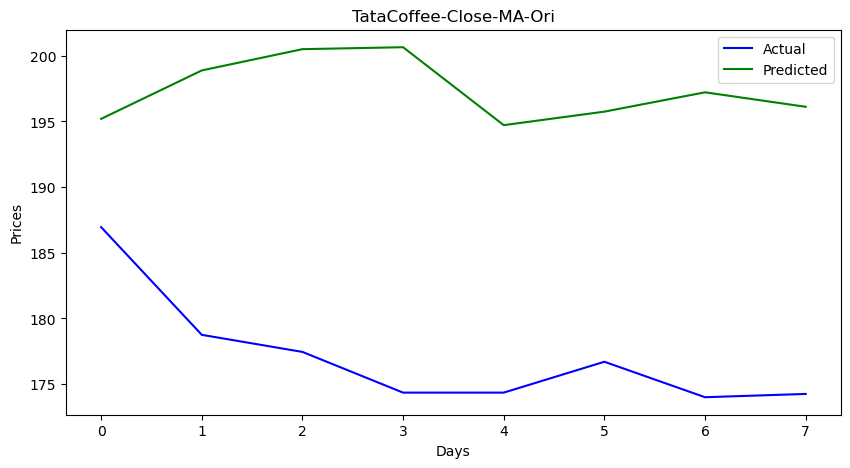

In [15]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-Close-MA-Ori","Days","Prices")

In [16]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 20.887178854997117
maPe-Testset: 0.11511032934035986


In [17]:
forecast=model_fit.predict(len(data1), len(data1))

In [18]:
forecast

array([0.34099498])

In [19]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [20]:
forecast_stock_price_test_oriF

,Closefore
0,194.348584


In [21]:
forecast_stock_price_test_oriF.to_csv("CloseMA.csv",index=False)